In [1]:
# Fix NumPy compatibility issue with scikit-surprise
!pip uninstall numpy -y -q
!pip install "numpy<2" -q
!pip uninstall scikit-surprise -y -q
!pip install scikit-surprise -q

print("✅ Done! Now go to Runtime → Restart Session")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [6]:
# Download directly in Colab — no manual upload needed!
!wget -q http://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip
print("✅ Dataset downloaded and extracted!")

replace ml-100k/allbut.pl? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/mku.sh? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ml-100k/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: ✅ Dataset downloaded and extracted!


In [7]:
# Load ratings
ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                      names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Load movie titles
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     usecols=[0, 1], names=['movie_id', 'title'])

# Merge
df = ratings.merge(movies, on='movie_id')

print("📊 Dataset Info:")
print(f"   Total Ratings : {len(df)}")
print(f"   Total Users   : {df['user_id'].nunique()}")
print(f"   Total Movies  : {df['movie_id'].nunique()}")
print(f"   Rating Range  : {df['rating'].min()} - {df['rating'].max()}")
print()
df.head()

📊 Dataset Info:
   Total Ratings : 100000
   Total Users   : 943
   Total Movies  : 1682
   Rating Range  : 1 - 5



,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


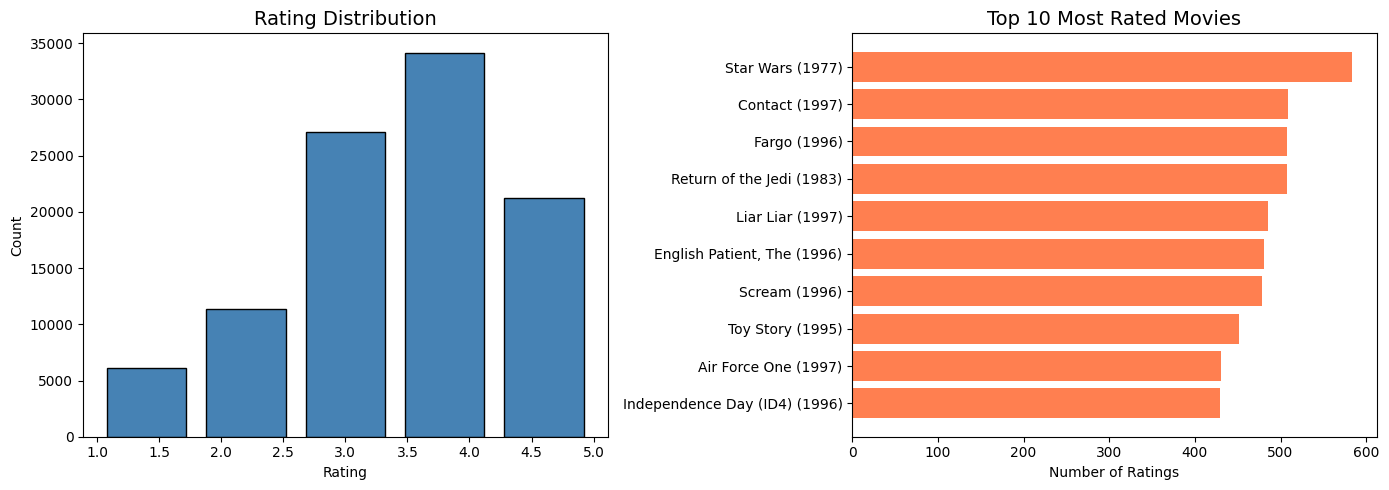

✅ Visualizations done!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
axes[0].hist(df['rating'], bins=5, color='steelblue', edgecolor='black', rwidth=0.8)
axes[0].set_title('Rating Distribution', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Top 10 most rated movies
top_movies = df.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
axes[1].barh(top_movies.index[::-1], top_movies.values[::-1], color='coral')
axes[1].set_title('Top 10 Most Rated Movies', fontsize=14)
axes[1].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.show()
print("✅ Visualizations done!")

In [9]:
# Pivot table: rows = users, columns = movies, values = ratings
movie_matrix = df.pivot_table(index='user_id',
                               columns='title',
                               values='rating')

# Fill missing ratings with 0
movie_matrix_filled = movie_matrix.fillna(0)

# Check sparsity
total_cells = movie_matrix.shape[0] * movie_matrix.shape[1]
filled_cells = df.shape[0]
sparsity = 1 - (filled_cells / total_cells)

print(f"✅ Matrix Shape : {movie_matrix.shape}")
print(f"   Users        : {movie_matrix.shape[0]}")
print(f"   Movies       : {movie_matrix.shape[1]}")
print(f"   Sparsity     : {sparsity:.2%}  ← Most values are 0!")

✅ Matrix Shape : (943, 1664)
   Users        : 943
   Movies       : 1664
   Sparsity     : 93.63%  ← Most values are 0!


In [10]:
# Convert to sparse matrix — TRANSPOSE so rows = movies, columns = users
# This way KNN finds similar MOVIES (not users)
movie_matrix_T = movie_matrix_filled.T  # Shape: (movies x users)
sparse_matrix = csr_matrix(movie_matrix_T.values)

# Train KNN with cosine similarity
model_knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=20,
    n_jobs=-1
)
model_knn.fit(sparse_matrix)

print("✅ KNN Model trained successfully!")
print(f"   Trained on shape : {sparse_matrix.shape}  ← (movies × users)")
print(f"   Metric    : Cosine Similarity")
print(f"   Neighbors : 20")

✅ KNN Model trained successfully!
   Trained on shape : (1664, 943)  ← (movies × users)
   Metric    : Cosine Similarity
   Neighbors : 20


In [11]:
def recommend_movies(movie_name, n_recommendations=10):
    movie_list = movie_matrix_T.index.tolist()  # ← rows are now movies

    # Fuzzy match — handles partial names
    matched = [m for m in movie_list if movie_name.lower() in m.lower()]

    if not matched:
        print(f"❌ Movie '{movie_name}' not found. Try another name.")
        return

    movie_name_full = matched[0]
    movie_idx = movie_list.index(movie_name_full)

    # Query: get the movie's row vector (1 movie × all users)
    distances, indices = model_knn.kneighbors(
        movie_matrix_T.iloc[movie_idx, :].values.reshape(1, -1),
        n_neighbors=n_recommendations + 1
    )

    print(f"\n🎬 Because you liked: '{movie_name_full}'")
    print(f"📽️  Top {n_recommendations} Recommendations:\n")
    print(f"{'Rank':<6} {'Movie Title':<50} {'Similarity'}")
    print("-" * 70)

    for i, (dist, idx) in enumerate(zip(distances[0][1:], indices[0][1:])):
        similarity = 1 - dist
        print(f"{i+1:<6} {movie_list[idx]:<50} {similarity:.2%}")

print("✅ Recommendation function ready!")

✅ Recommendation function ready!


In [13]:
# 🎯 Try different movies!
recommend_movies("Star Wars", n_recommendations=8)


🎬 Because you liked: 'Star Wars (1977)'
📽️  Top 8 Recommendations:

Rank   Movie Title                                        Similarity
----------------------------------------------------------------------
1      Return of the Jedi (1983)                          88.45%
2      Raiders of the Lost Ark (1981)                     76.49%
3      Empire Strikes Back, The (1980)                    74.98%
4      Toy Story (1995)                                   73.46%
5      Godfather, The (1972)                              69.73%
6      Independence Day (ID4) (1996)                      69.28%
7      Indiana Jones and the Last Crusade (1989)          68.93%
8      Fargo (1996)                                       68.65%


In [12]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate, train_test_split

# Load into Surprise format
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['user_id', 'movie_id', 'rating']], reader)

# Train SVD
svd_model = SVD(n_factors=50, n_epochs=20, random_state=42)

print("🔄 Running 5-Fold Cross Validation on SVD...\n")
results = cross_validate(svd_model, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print(f"\n✅ SVD Results:")
print(f"   Average RMSE : {results['test_rmse'].mean():.4f}")
print(f"   Average MAE  : {results['test_mae'].mean():.4f}")
print(f"   (Lower is better | Target: RMSE < 1.0 ✅)")

🔄 Running 5-Fold Cross Validation on SVD...

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9350  0.9368  0.9371  0.9383  0.9365  0.9367  0.0011  
MAE (testset)     0.7379  0.7402  0.7378  0.7397  0.7390  0.7389  0.0009  
Fit time          1.37    1.91    1.48    1.24    0.95    1.39    0.31    
Test time         0.12    0.34    0.34    0.14    0.12    0.21    0.10    

✅ SVD Results:
   Average RMSE : 0.9367
   Average MAE  : 0.7389
   (Lower is better | Target: RMSE < 1.0 ✅)


In [14]:
# Train on full data
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
svd_model.fit(trainset)

# Predict: What would User 1 rate Movie 50?
user_id = 1
movie_id = 50
movie_title = movies[movies['movie_id'] == movie_id]['title'].values[0]

pred = svd_model.predict(uid=user_id, iid=movie_id)

print(f"🔮 SVD Prediction:")
print(f"   User ID    : {user_id}")
print(f"   Movie      : {movie_title}")
print(f"   Predicted Rating : {pred.est:.2f} / 5.0")

🔮 SVD Prediction:
   User ID    : 1
   Movie      : Star Wars (1977)
   Predicted Rating : 4.69 / 5.0


In [15]:
# 🎮 Run this cell and type any movie name!
movie_input = input("🎬 Enter a movie name to get recommendations: ")
recommend_movies(movie_input, n_recommendations=10)

🎬 Enter a movie name to get recommendations: Star Wars 

🎬 Because you liked: 'Star Wars (1977)'
📽️  Top 10 Recommendations:

Rank   Movie Title                                        Similarity
----------------------------------------------------------------------
1      Return of the Jedi (1983)                          88.45%
2      Raiders of the Lost Ark (1981)                     76.49%
3      Empire Strikes Back, The (1980)                    74.98%
4      Toy Story (1995)                                   73.46%
5      Godfather, The (1972)                              69.73%
6      Independence Day (ID4) (1996)                      69.28%
7      Indiana Jones and the Last Crusade (1989)          68.93%
8      Fargo (1996)                                       68.65%
9      Silence of the Lambs, The (1991)                   67.64%
10     Star Trek: First Contact (1996)                    67.40%


In [16]:
print("=" * 60)
print("   🎬 MOVIE RECOMMENDATION SYSTEM — PROJECT SUMMARY")
print("=" * 60)
print(f"""
📌 Project   : Movie Recommendation System
🏢 For       : Webosphere Interview
📦 Dataset   : MovieLens 100K (GroupLens Research)

📊 Data Stats:
   • {len(df):,} total ratings
   • {df['user_id'].nunique()} users
   • {df['movie_id'].nunique()} movies
   • {sparsity:.1%} matrix sparsity

🤖 Algorithms:
   • KNN  → Item-based Collaborative Filtering
            Metric: Cosine Similarity
            Neighbors: 20

   • SVD  → Matrix Factorization
            Factors: 50 | Epochs: 20
            RMSE: {results['test_rmse'].mean():.4f}
            MAE : {results['test_mae'].mean():.4f}

🛠️  Tech Stack:
   Python, Pandas, NumPy, Scikit-learn,
   Surprise, SciPy, Matplotlib

✅ Key Concepts:
   • Collaborative Filtering
   • Cosine Similarity
   • Sparse Matrix
   • Cold Start Problem
   • RMSE / MAE Evaluation
""")
print("=" * 60)

   🎬 MOVIE RECOMMENDATION SYSTEM — PROJECT SUMMARY

📌 Project   : Movie Recommendation System
🏢 For       : Webosphere Interview
📦 Dataset   : MovieLens 100K (GroupLens Research)

📊 Data Stats:
   • 100,000 total ratings
   • 943 users
   • 1682 movies
   • 93.6% matrix sparsity

🤖 Algorithms:
   • KNN  → Item-based Collaborative Filtering
            Metric: Cosine Similarity
            Neighbors: 20
   
   • SVD  → Matrix Factorization
            Factors: 50 | Epochs: 20
            RMSE: 0.9367
            MAE : 0.7389

🛠️  Tech Stack:
   Python, Pandas, NumPy, Scikit-learn,
   Surprise, SciPy, Matplotlib

✅ Key Concepts:
   • Collaborative Filtering
   • Cosine Similarity
   • Sparse Matrix
   • Cold Start Problem
   • RMSE / MAE Evaluation

